# Models

### Read this carefully before starting

This file contains multiple models applied on the dataset, make a copy of the whole folder before proceeding
1. The code contains mistakes and generates comparisons between the wrong features (columns from the csv). Your job is to use `data_analysis.ipynb` to find the correct relationships to achieve maximum accuracy 

2. The code also uses wrong hyperparameters for the model training, along with comments saying `TODO` wherever there might be mistakes, use your machine learning knowledge and the comments to fix those mistakes

3. You are not encouraged to change anything else other than what is mentioned by `TODO` however you are also not forbidden, you can make extra models, change existing ones completely or do whatever you want in this notebook with this dataset

#### Submission:
After you have made all changes and have your final code, hit `Run All` at the top and a folder will be generated/updates saved at `./models`. Zip this folder and rename it to your delegation name only. Then send it to the provided link for final submission.

## Definitions

**Imports:**

In [76]:
# Standard library
import json
import os
import warnings

# Third-party
import joblib
import matplotlib.pyplot as plt
import pandas as pd

# Scikit-learn
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR

# Suppress convergence warnings from MLP
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

**Helper functions to use in later blocks:**

In [77]:
def _to_json_serializable(value):
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    if hasattr(value, "item") and callable(getattr(value, "item")):
        try:
            return value.item()
        except Exception:
            pass
    if isinstance(value, dict):
        return {str(k): _to_json_serializable(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [_to_json_serializable(v) for v in value]
    return str(value)


def initialize_metrics(feature_cols):
    """Initialize the metrics JSON file with feature columns at the start."""
    MODEL_DIR = "../models"
    METRICS_PATH = os.path.join(MODEL_DIR, "model_metrics.json")
    
    metrics = {
        "feature_columns": list(feature_cols),
        "models": {}
    }
    
    with open(METRICS_PATH, "w") as f:
        json.dump(metrics, f, indent=4)
    
    print(f"Initialized metrics file with {len(feature_cols)} feature columns")


def evaluate_model(model_name, hyperparameters):
    MODEL_DIR = "../models"
    model_path = os.path.join(MODEL_DIR, model_name + ".joblib")

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")

    model = joblib.load(model_path)

    global X_test, y_test

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Evaluation metrics for {model_name}:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R^2: {r2:.4f}")

    METRICS_PATH = os.path.join(MODEL_DIR, "best_model_metrics.json")
    metrics = {}
    if os.path.exists(METRICS_PATH):
        with open(METRICS_PATH, "r") as f:
            metrics = json.load(f)

    if "models" not in metrics:
        metrics["models"] = {}

    metrics["models"][model_name] = {
        "MSE": float(mse),
        "MAE": float(mae),
        "R2": float(r2),
        "hyperparameters": _to_json_serializable(hyperparameters),
    }

    with open(METRICS_PATH, "w") as f:
        json.dump(metrics, f, indent=4)

    return y_pred


def plot_predictions(y_true, y_pred, model_name):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.6, edgecolors='k')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel("Actual " + target_column)
    plt.ylabel("Predicted " + target_column)
    plt.title(f"Predicted vs Actual Values ({model_name})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Read Data

In [78]:
# read the csv file
df = pd.read_csv("../data/dataset.csv")

target_column = "power_consumption" # do not change this line

feature_columns = [col for col in df.columns if col != target_column]  # TODO find best features from data_analysis.ipynb

# Prepare data
X = df[feature_columns]
y = df[target_column]

# split data for train & test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# constants
model_name = ""
MODEL_DIR = "../models"

# Initialize metrics file with feature columns
initialize_metrics(feature_columns)

Initialized metrics file with 10 feature columns


## Polynomial Regression

Evaluation metrics for polynomial_regression:
MSE: 856.9860
MAE: 22.7280
R^2: 0.8102


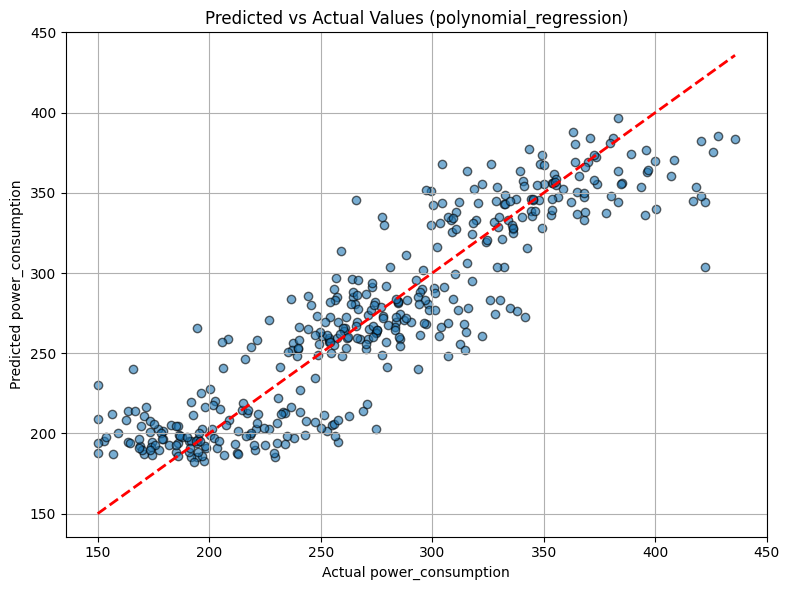

In [79]:
# Model save directory
model_name = "polynomial_regression"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# Hyperparameters
degree = 2              # Changed from 1 to 2
include_bias = True     # Changed from False to True

X_train_model = X_train[feature_columns]
X_test_model = X_test[feature_columns]

hyperparameters = {
    "degree": degree,
    "include_bias": include_bias,
    "fit_intercept": True,
    "features_used": feature_columns,
}

# Training model
model = make_pipeline(
    PolynomialFeatures(degree, include_bias=include_bias),
    LinearRegression(fit_intercept=True)  # Changed from False to True
)
model.fit(X_train_model, y_train)

# Saving model
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and plot
predictions = evaluate_model(model_name, hyperparameters)
plot_predictions(y_test, predictions, model_name)

## Random Forest Regression

Evaluation metrics for random_forest_regression:
MSE: 838.0265
MAE: 22.6485
R^2: 0.8144


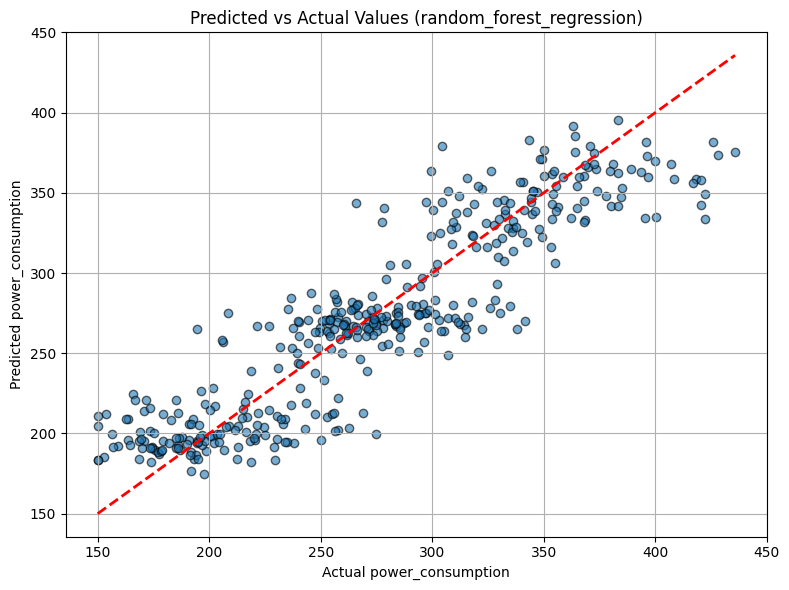

In [80]:
# Model save directory
model_name = "random_forest_regression"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# Hyperparameters
n_estimators = 200      # Changed from 3 to 200
max_depth = None        # Changed from 1 to None
min_samples_split = 2   # Changed from 100 to 2
min_samples_leaf = 1    # Changed from 50 to 1
max_features = "sqrt"   # Changed from 0.2 to "sqrt"
random_state = 42

X_train_model = X_train[feature_columns]
X_test_model = X_test[feature_columns]

hyperparameters = {
    "n_estimators": n_estimators,
    "max_depth": max_depth,
    "min_samples_split": min_samples_split,
    "min_samples_leaf": min_samples_leaf,
    "max_features": max_features,
    "random_state": random_state,
    "n_jobs": -1,
    "features_used": feature_columns,
}

# Training model
model = RandomForestRegressor(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf,
    max_features=max_features,
    random_state=random_state,
    n_jobs=-1,
)
model.fit(X_train_model, y_train)

# Saving model
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and plot
predictions = evaluate_model(model_name, hyperparameters)
plot_predictions(y_test, predictions, model_name)

## Multi-Layer-Perceptron Regression

Evaluation metrics for mlp_regressor:
MSE: 868.4432
MAE: 23.2436
R^2: 0.8077


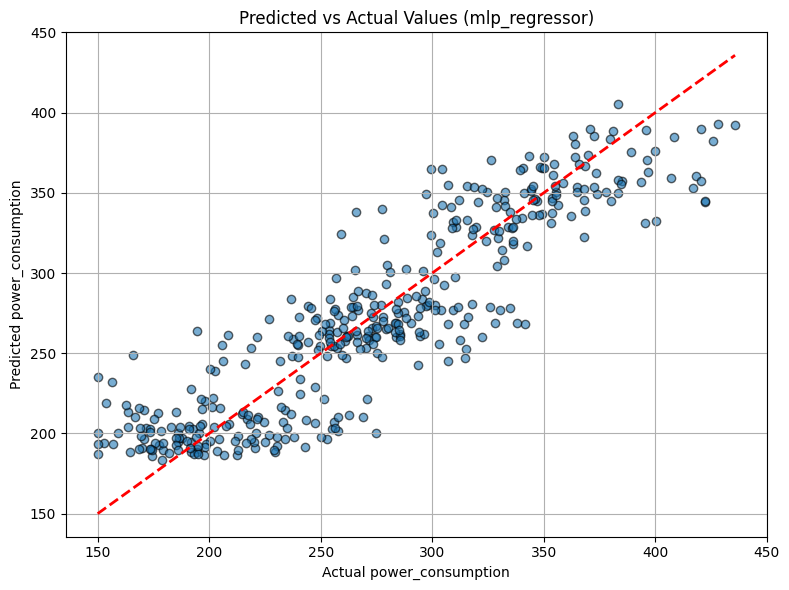

In [81]:
# Model save directory
model_name = "mlp_regressor"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# Hyperparameters
hidden_layer_sizes = (128, 64)  # Changed from (4,) to (128, 64)
activation = "relu"             # Changed from "tanh" to "relu"
solver = "adam"                 # Changed from "sgd" to "adam"
max_iter = 2000                 # Changed from 30 to 2000
random_state = 42
alpha = 0.0001                  # Changed from 100.0 to 0.0001
learning_rate_init = 0.001      # Changed from 0.0005 to 0.001
early_stopping = True

X_train_model = X_train[feature_columns]
X_test_model = X_test[feature_columns]

hyperparameters = {
    "hidden_layer_sizes": hidden_layer_sizes,
    "activation": activation,
    "solver": solver,
    "max_iter": max_iter,
    "random_state": random_state,
    "alpha": alpha,
    "learning_rate_init": learning_rate_init,
    "early_stopping": early_stopping,
    "scaled": True,
    "features_used": feature_columns,
}

# Training model
model = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        early_stopping=early_stopping,
        random_state=random_state,
    ),
)
model.fit(X_train_model, y_train)

# Saving model
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and plot
predictions = evaluate_model(model_name, hyperparameters)
plot_predictions(y_test, predictions, model_name)

## Support Vector Regression

Evaluation metrics for svr_regressor:
MSE: 848.6176
MAE: 22.6839
R^2: 0.8121


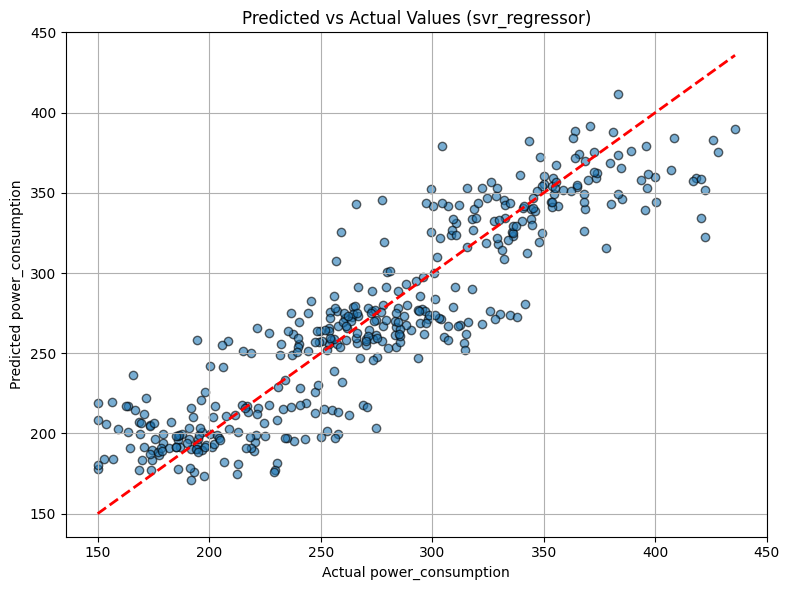

In [82]:
# Model save directory
model_name = "svr_regressor"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# Hyperparameters
kernel = "rbf"          # Changed from "poly" to "rbf"
C = 100.0               # Changed from 0.3 to 100.0
epsilon = 0.1           # Changed from 15.0 to 0.1
gamma = "scale"         # Changed from 0.01 to "scale"

X_train_model = X_train[feature_columns]
X_test_model = X_test[feature_columns]

hyperparameters = {
    "kernel": kernel,
    "C": C,
    "epsilon": epsilon,
    "gamma": gamma,
    "scaled": True,
    "features_used": feature_columns,
}

# Training model
model = make_pipeline(
    StandardScaler(),
    SVR(kernel=kernel, C=C, epsilon=epsilon, gamma=gamma),
)
model.fit(X_train_model, y_train)

# Saving model
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and plot
predictions = evaluate_model(model_name, hyperparameters)
plot_predictions(y_test, predictions, model_name)

## Elastic Net

Evaluation metrics for elastic_net_regression:
MSE: 823.5391
MAE: 22.5453
R^2: 0.8176


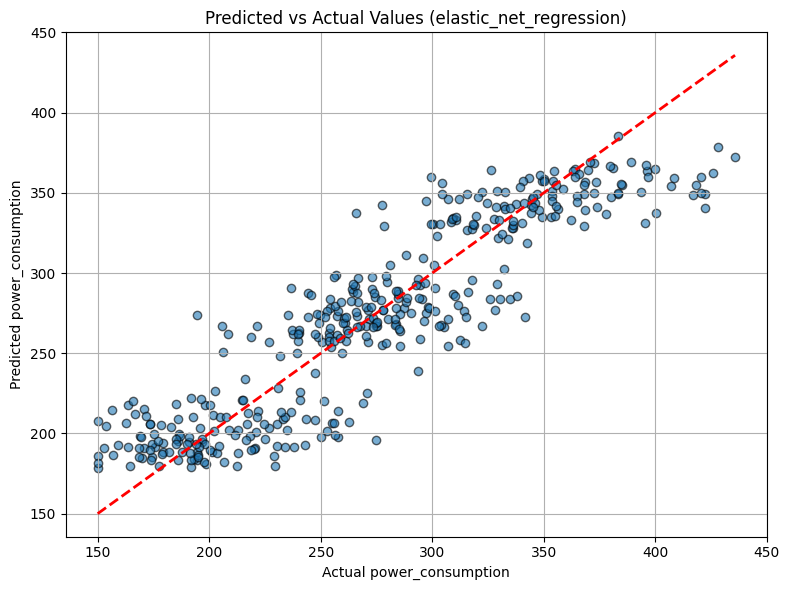

In [83]:
# Model save directory
model_name = "elastic_net_regression"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# Hyperparameters
alpha = 0.001           # Changed from 15.0 to 0.001
l1_ratio = 0.5          # Changed from 0.8 to 0.5
max_iter = 2000         # Changed from 500 to 2000
random_state = 42

X_train_model = X_train[feature_columns]
X_test_model = X_test[feature_columns]

hyperparameters = {
    "alpha": alpha,
    "l1_ratio": l1_ratio,
    "max_iter": max_iter,
    "random_state": random_state,
    "scaled": True,
    "features_used": feature_columns,
}

# Training model
model = make_pipeline(
    StandardScaler(),
    ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=max_iter, random_state=random_state),
)
model.fit(X_train_model, y_train)

# Saving model
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and plot
predictions = evaluate_model(model_name, hyperparameters)
plot_predictions(y_test, predictions, model_name)